# <font color=blue> Actividad Operaciones Morfológicas y transformada de Hough</font>


**Nombre:** Manuel Ramírez Galván

**Actividad:** 4

**Fecha:** 03/03/2025

**Objetivos:**
Comprender y aplicar las operaciones morfológicas y la Transformada de Hough en imágenes digitales para mejorar la segmentación, detección de formas y análisis de estructuras en imágenes.

## <font color=green> Ejercicio 1:  Importar bibliotecas necesarias</font>

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## <font color=green> Ejercicio 2: Aplicación de Operaciones Morfológicas (Dilatación y Erosión) </font>

**Objetivo:** Aplicar dilatación y erosión en una imagen binaria para comprender su efecto en la forma de los objetos.

**Pasos:**
1.   Cargar la imagen en escala de grises y convertirla en binaria mediante un umbral.
2.   Definir un elemento estructurante `(kernel)` para las operaciones morfológicas.
3.   Aplicar dilatación `(cv2.dilate())` para expandir los objetos en la imagen.
4.   Aplicar erosión `(cv2.erode())` para reducir el tamaño de los objetos.
5.   Visualizar la imagen original, la dilatada y la erosionada. Utilizando `cv2.imwrite()`


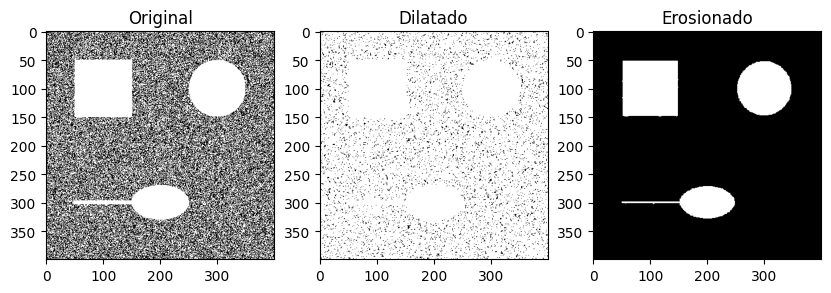

In [62]:
img1 = cv2.imread("C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL2/2_4_Operaciones_Morfologicas_TransformadaHough/data/Morfologicas.png")

kernel1 = np.ones((2,2), np.uint8)
dilated = cv2.dilate(img1, kernel1, iterations=1)

kernel2 = np.ones((5,5), np.uint8)
eroded = cv2.erode(img1, kernel2, iterations=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img1, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Dilatado")
plt.imshow(dilated, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("Erosionado")
plt.imshow(eroded, cmap='gray')
plt.show()

## <font color=green> Ejercicio 3: Aplicación de Operaciones Morfológicas (Apertura y Cierre)  </font>

**Objetivo:** Utilizar apertura y cierre en una imagen binaria para suavizar contornos y eliminar ruido.

**Pasos:**
1.   Cargar la imagen en escala de grises y convertirla en binaria.
2.   Definir un `kernel` para las operaciones morfológicas.
3.   Aplicar apertura `(cv2.morphologyEx() con MORPH_OPEN)` para eliminar ruido.
4.   Aplicar cierre `(cv2.morphologyEx() con MORPH_CLOSE)` para cerrar pequeños huecos en los objetos.
5.   Visualizar la imagen original, con apertura y cierre. Utilizando `cv2.imwrite()`

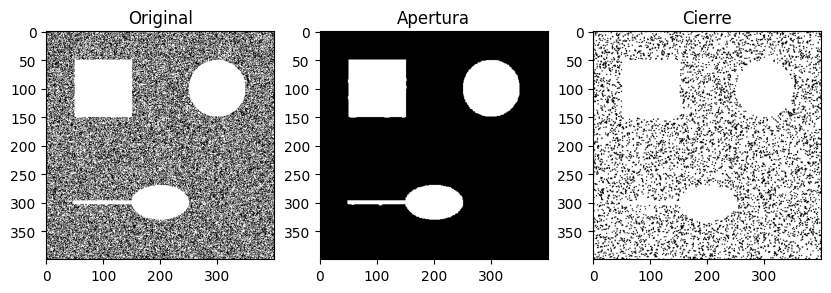

In [63]:
kernel3 = np.ones((5,5), np.uint8)
kernel4 = np.ones((2,2), np.uint8)

opened = cv2.morphologyEx(img1, cv2.MORPH_OPEN, kernel3)
closed = cv2.morphologyEx(img1, cv2.MORPH_CLOSE, kernel4)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img1, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Apertura")
plt.imshow(opened, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("Cierre")
plt.imshow(closed, cmap='gray')
plt.show()

## <font color=green> Ejercicio 4:  Cálculo de Momentos de una Imagen </font>

**Objetivo:** Calcular los momentos de una imagen para identificar propiedades geométricas como el centro de masa (centroide) y visualizarlo sobre la imagen.

**Pasos:**
1.   Cargar la imagen en escala de grises y convertirla en binaria si no lo está.
2.   Calcular los momentos de la imagen usando `cv2.moments()`.
3.   Obtener el centroide de la imagen a partir de los momentos.
4.   Imprimir los valores de los momentos y las coordenadas del centroide.
5.   Convertir la imagen a color para poder dibujar el centroide.
6.   Dibujar el centroide en la imagen usando `cv2.circle().`
7.   Visualizar la imagen original con el centroide marcado usando `plt.imshow()`.

Centro de masa: (725, 742)


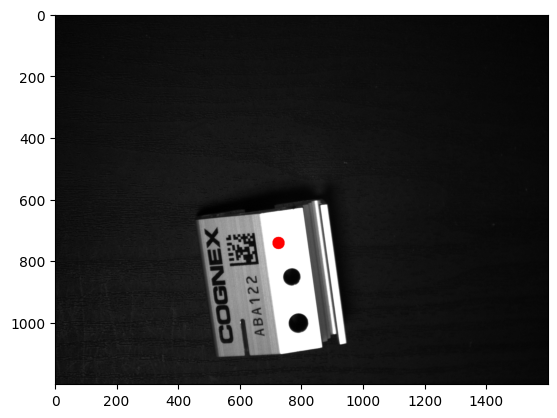

In [64]:
img2 = cv2.imread("C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL2/2_4_Operaciones_Morfologicas_TransformadaHough/data/Block.BMP")
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

moments = cv2.moments(gray_img2)

cx = int(moments['m10'] / moments['m00'])
cy = int(moments['m01'] / moments['m00'])

print("Centro de masa: ({}, {})".format(cx, cy))

circulo = cv2.circle(img2, (cx, cy), 20, (255, 0, 0), -1)
plt.imshow(circulo)

## <font color=green> Ejercicio 5:  Transformada de Hough para Detección de Líneas </font>

**Objetivo:** Detectar líneas rectas en una imagen utilizando la Transformada de Hough.

**Pasos:**
1.   Cargar la imagen en escala de grises.
2.   Aplicar detección de bordes con Canny `(cv2.Canny())`.
3.   Aplicar la Transformada de Hough para líneas `(cv2.HoughLines())`.
4.   Dibujar las líneas detectadas sobre la imagen original.
5.   Visualizar la imagen con las lineas de hough. Utilizando `cv2.imwrite()`

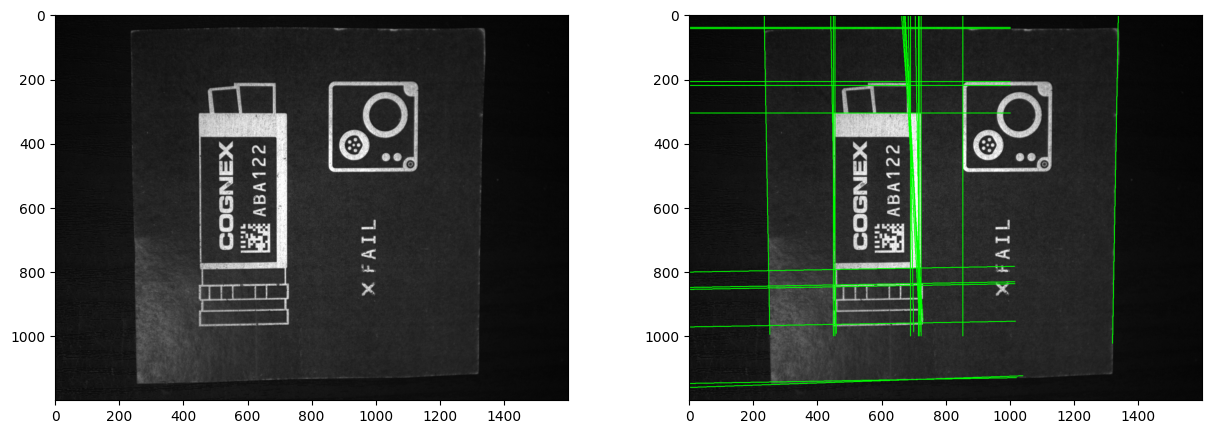

In [65]:
img3 = cv2.imread("C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL2/2_4_Operaciones_Morfologicas_TransformadaHough/data/Plate.BMP")

gray_img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
img_lines = cv2.cvtColor(gray_img3, cv2.COLOR_GRAY2BGR)

canny = cv2.Canny(img3, 50, 150)
lines = cv2.HoughLines(canny, 1, np.pi/180, 200)

if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(img3, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img_lines)
plt.show()


## <font color=green> Ejercicio 6: Transformada de Hough para Detección de Círculos </font>

**Objetivo:** Detectar círculos en una imagen utilizando la Transformada de Hough Circular.

**Pasos:**
1.   Cargar la imagen en escala de grises.
2.   Aplicar un filtro para reducir ruido `(cv2.medianBlur())`.
3.   Aplicar la Transformada de Hough para círculos `(cv2.HoughCircles())`.
4.   Dibujar los círculos detectados en la imagen.
5.   Visualizar la imagen con las lineas de hough. Utilizando `cv2.imwrite()`

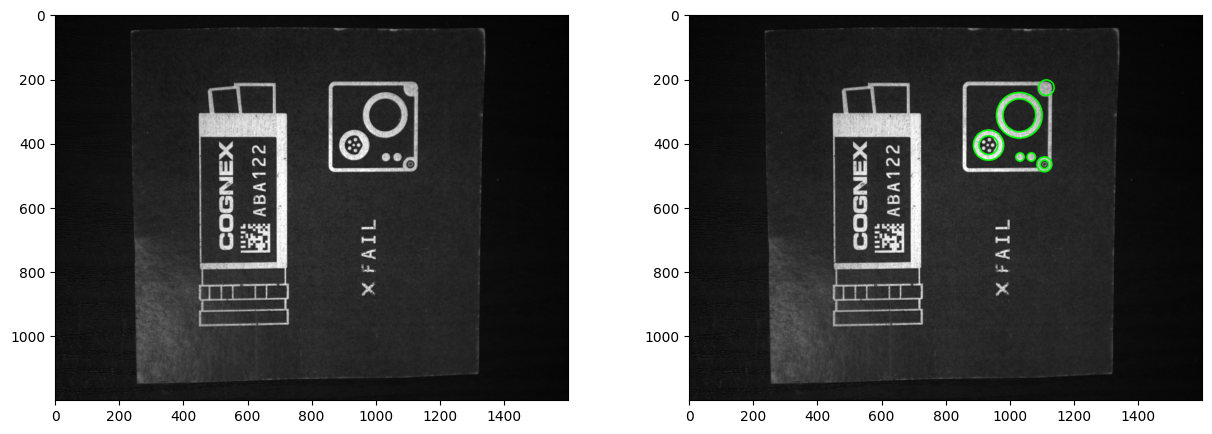

In [66]:
img4 = cv2.imread("C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL2/2_4_Operaciones_Morfologicas_TransformadaHough/data/Block.BMP")

gray_img4 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
img_circle = cv2.cvtColor(gray_img4, cv2.COLOR_GRAY2BGR)

blurred = cv2.medianBlur(gray_img4, 5)
circle = np.uint16(np.around(cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT_ALT, 1.5, 20, param1=50, param2=0.95, minRadius=10, maxRadius=80)))

if circle is not None:
    for i in circle[0, :]:
        cv2.circle(img_circle, (i[0], i[1]), i[2], (0, 255, 0), 3)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_img4, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img_circle)
plt.show()